<a href="https://colab.research.google.com/github/Tharunkoneti18/MLE/blob/main/face-recog/mle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── Standard Libraries ───────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── Aesthetics ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
N_COMPONENTS = 150   # number of PCA components (Eigenfaces)

print('✅ All imports successful.')

✅ All imports successful.


In [2]:
print('📦 Fetching LFW dataset (this may take a moment on first run)...')
lfw_dataset = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# ── Unpack ────────────────────────────────────────────────────────────────────
X_images = lfw_dataset.images          # shape: (n_samples, h, w)
X        = lfw_dataset.data            # shape: (n_samples, h*w)  — already flattened
y        = lfw_dataset.target          # integer class labels
names    = lfw_dataset.target_names    # string names per class

n_samples, h, w = X_images.shape
n_features      = X.shape[1]
n_classes       = len(names)

print(f'\n📊 Dataset Summary')
print(f'   Samples   : {n_samples}')
print(f'   Image size: {h} × {w} pixels')
print(f'   Features  : {n_features} (= {h}×{w})')
print(f'   Classes   : {n_classes}')
print(f'\n👤 Subjects:')
for i, name in enumerate(names):
    count = np.sum(y == i)
    bar   = '█' * (count // 5)
    print(f'   [{i}] {name:<25} {count:>3} samples  {bar}')

📦 Fetching LFW dataset (this may take a moment on first run)...

📊 Dataset Summary
   Samples   : 1288
   Image size: 50 × 37 pixels
   Features  : 1850 (= 50×37)
   Classes   : 7

👤 Subjects:
   [0] Ariel Sharon               77 samples  ███████████████
   [1] Colin Powell              236 samples  ███████████████████████████████████████████████
   [2] Donald Rumsfeld           121 samples  ████████████████████████
   [3] George W Bush             530 samples  ██████████████████████████████████████████████████████████████████████████████████████████████████████████
   [4] Gerhard Schroeder         109 samples  █████████████████████
   [5] Hugo Chavez                71 samples  ██████████████
   [6] Tony Blair                144 samples  ████████████████████████████


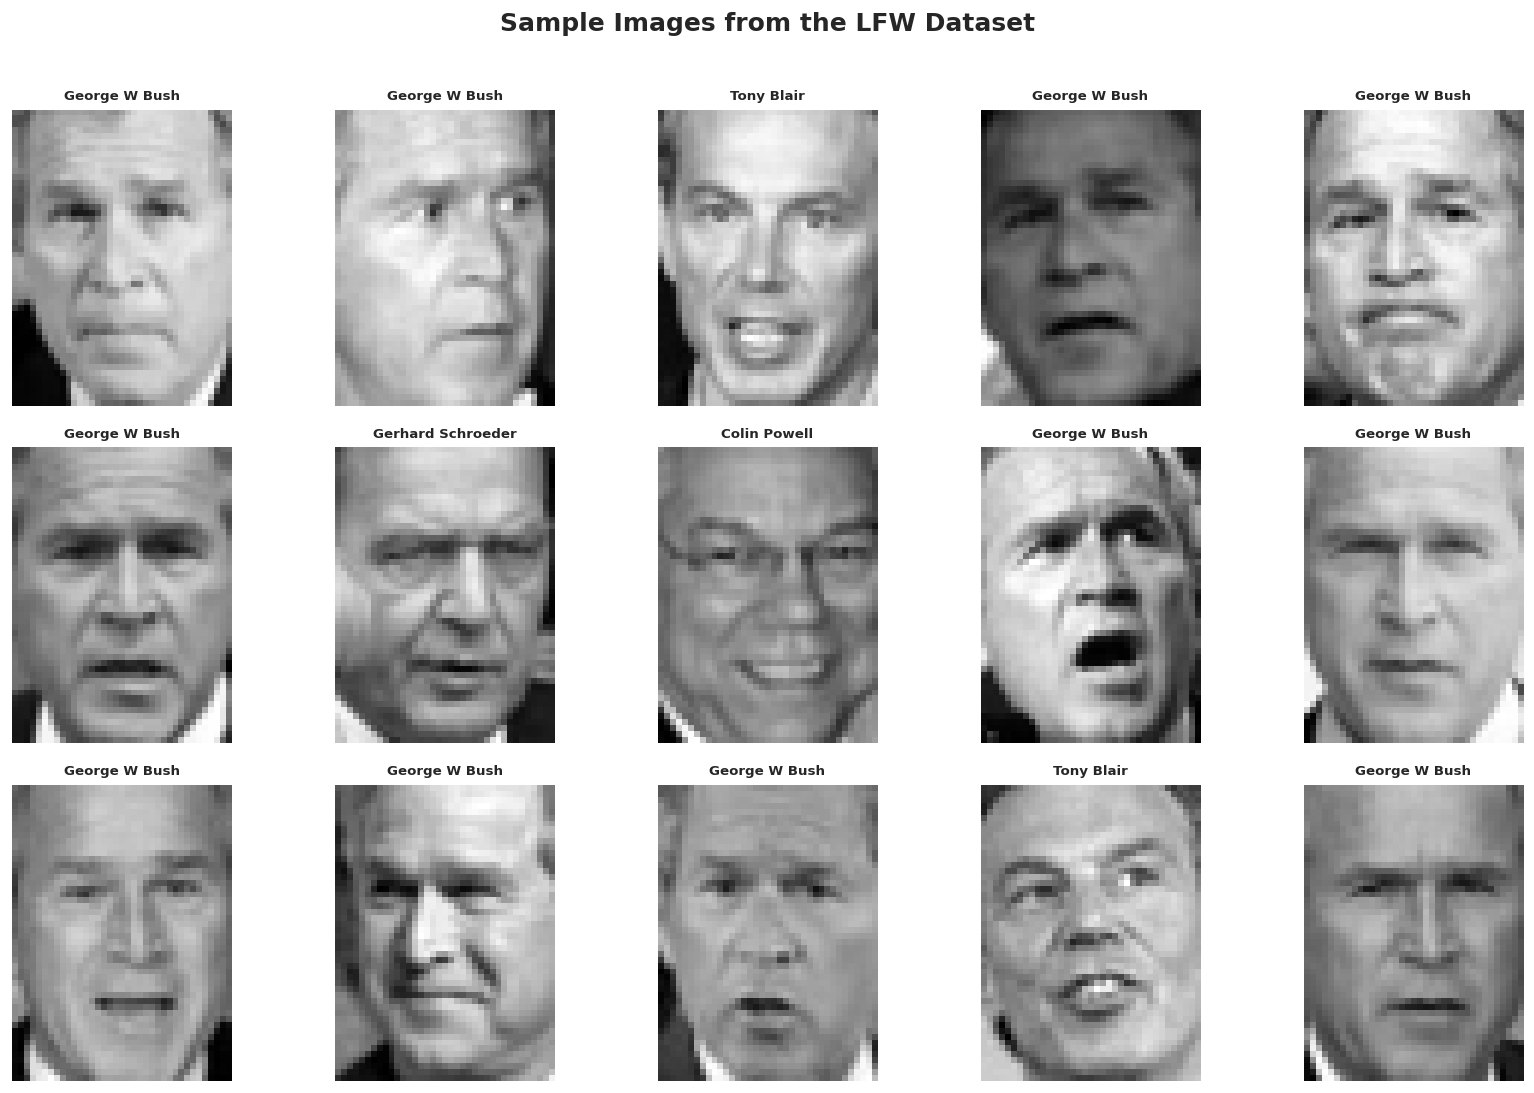

In [3]:
# ── Visualise a sample grid ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(14, 9))
fig.suptitle('Sample Images from the LFW Dataset', fontsize=15, fontweight='bold', y=1.01)

indices = np.random.RandomState(RANDOM_STATE).choice(n_samples, 15, replace=False)
for ax, idx in zip(axes.ravel(), indices):
    ax.imshow(X_images[idx], cmap='gray')
    ax.set_title(names[y[idx]], fontsize=8, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

Train samples : 966
Test  samples : 322


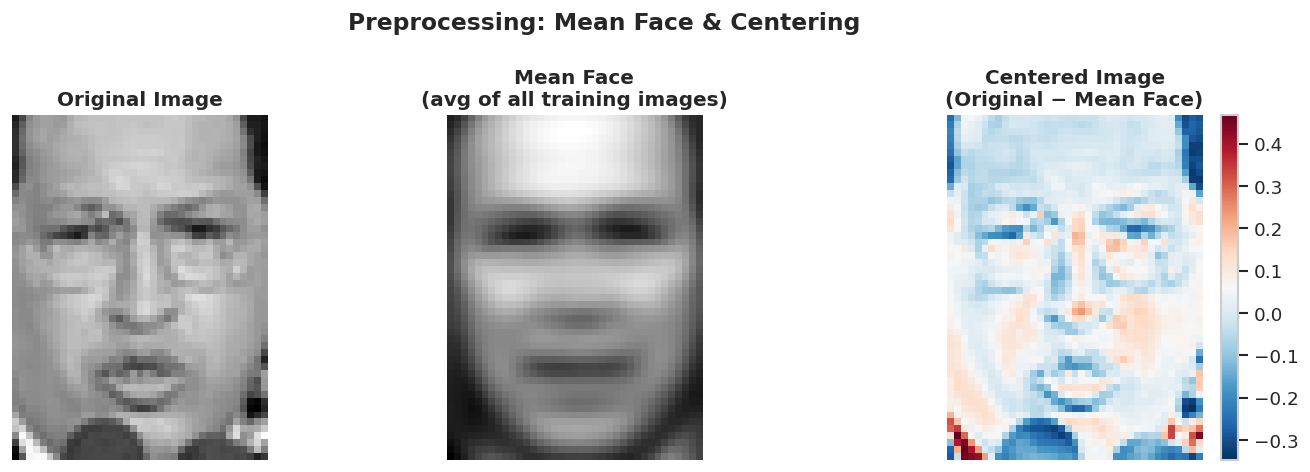


✅ Data centered. Train mean ≈ -1.52e-08 (should be ~0)


In [4]:
# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f'Train samples : {X_train.shape[0]}')
print(f'Test  samples : {X_test.shape[0]}')

# ── Compute Mean Face on TRAINING data only (no data leakage) ─────────────────
mean_face_vec = X_train.mean(axis=0)          # shape: (n_features,)
mean_face_img = mean_face_vec.reshape(h, w)

# ── Center both splits ────────────────────────────────────────────────────────
X_train_centered = X_train - mean_face_vec
X_test_centered  = X_test  - mean_face_vec

# ── Visualise the Mean Face ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Preprocessing: Mean Face & Centering', fontsize=14, fontweight='bold')

sample_idx = 0
original_img   = X_train[sample_idx].reshape(h, w)
centered_img   = X_train_centered[sample_idx].reshape(h, w)

axes[0].imshow(original_img, cmap='gray')
axes[0].set_title('Original Image', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mean_face_img, cmap='gray')
axes[1].set_title('Mean Face\n(avg of all training images)', fontweight='bold')
axes[1].axis('off')

im = axes[2].imshow(centered_img, cmap='RdBu_r')
axes[2].set_title('Centered Image\n(Original − Mean Face)', fontweight='bold')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
print(f'\n✅ Data centered. Train mean ≈ {X_train_centered.mean():.2e} (should be ~0)')

In [5]:
# ── Fit PCA on centered TRAINING data ────────────────────────────────────────
print(f'🔄 Running PCA with {N_COMPONENTS} components...')
pca = PCA(n_components=N_COMPONENTS, svd_solver='randomized', random_state=RANDOM_STATE)
pca.fit(X_train_centered)

# ── Project both splits ───────────────────────────────────────────────────────
X_train_pca = pca.transform(X_train_centered)  # (n_train, 150)
X_test_pca  = pca.transform(X_test_centered)   # (n_test,  150)

print(f'✅ PCA complete.')
print(f'   Training projection shape : {X_train_pca.shape}')
print(f'   Test     projection shape : {X_test_pca.shape}')
print(f'   Variance explained by {N_COMPONENTS} components: '
      f'{pca.explained_variance_ratio_.sum()*100:.1f}%')

🔄 Running PCA with 150 components...
✅ PCA complete.
   Training projection shape : (966, 150)
   Test     projection shape : (322, 150)
   Variance explained by 150 components: 94.6%


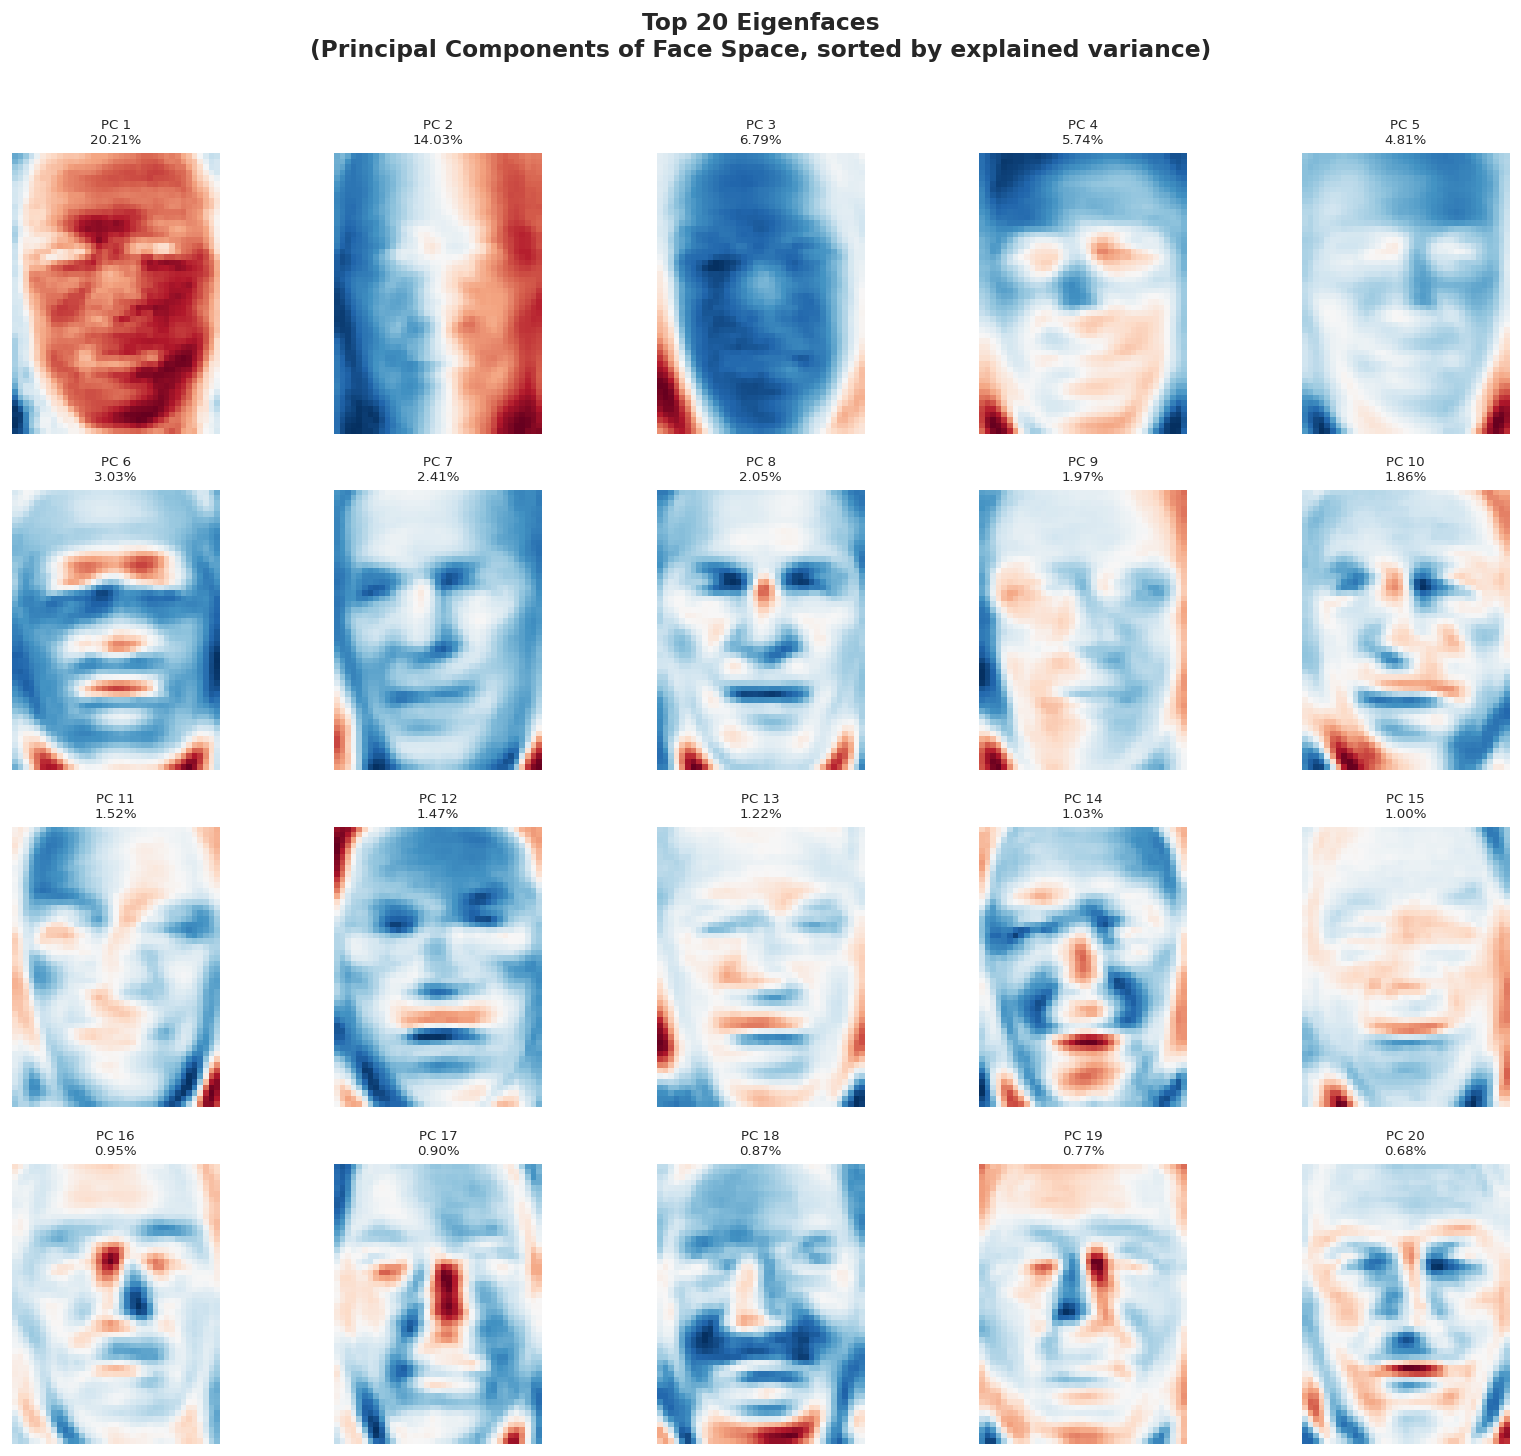

💡 Early eigenfaces capture coarse global structure (lighting, pose); later ones capture fine details.


In [6]:
# ── Visualise top-20 Eigenfaces ───────────────────────────────────────────────
N_DISPLAY = 20
eigenfaces = pca.components_[:N_DISPLAY].reshape((N_DISPLAY, h, w))

fig, axes = plt.subplots(4, 5, figsize=(14, 12))
fig.suptitle(
    f'Top {N_DISPLAY} Eigenfaces\n'
    '(Principal Components of Face Space, sorted by explained variance)',
    fontsize=14, fontweight='bold', y=1.01
)

for i, (ax, ef) in enumerate(zip(axes.ravel(), eigenfaces)):
    variance_pct = pca.explained_variance_ratio_[i] * 100
    ax.imshow(ef, cmap='RdBu_r')
    ax.set_title(f'PC {i+1}\n{variance_pct:.2f}%', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()
print('💡 Early eigenfaces capture coarse global structure (lighting, pose);'
      ' later ones capture fine details.')

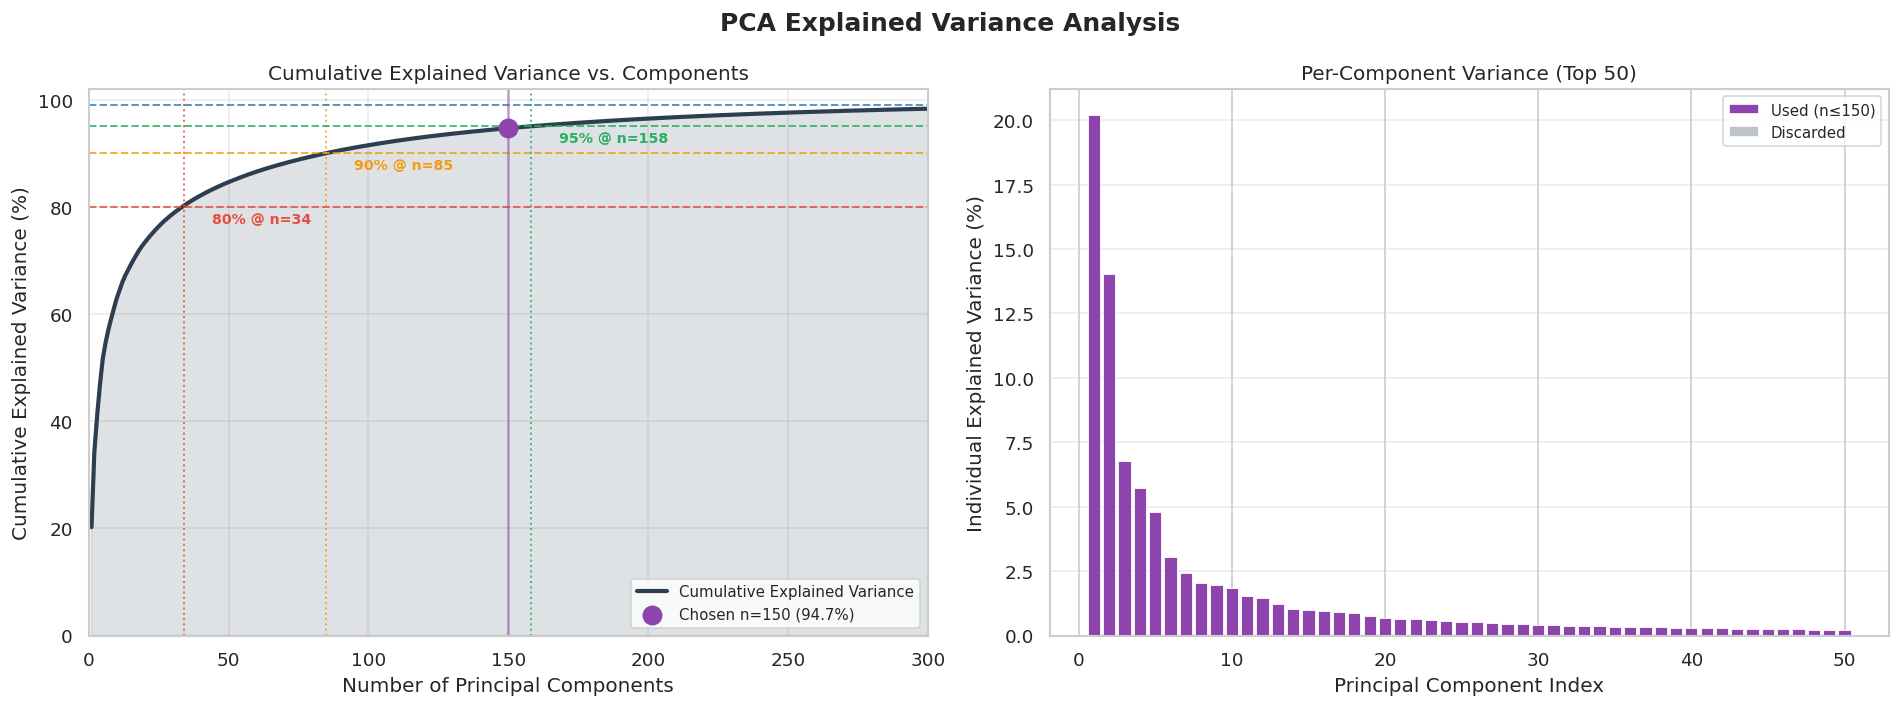


📊 Variance Summary:
   80% variance needs 34 components
   90% variance needs 85 components
   95% variance needs 158 components
   99% variance needs 379 components
   Our n=150 captures 94.7% of total variance ✅


In [7]:
# ── Fit a full PCA (all components) for the variance plot ─────────────────────
pca_full = PCA(svd_solver='randomized', random_state=RANDOM_STATE)
pca_full.fit(X_train_centered)

cumvar   = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_comps  = np.arange(1, len(cumvar) + 1)

# ── Thresholds ────────────────────────────────────────────────────────────────
def comp_at_threshold(threshold):
    return np.searchsorted(cumvar, threshold) + 1

thresholds = [80, 90, 95, 99]
colors_t   = ['#e74c3c', '#f39c12', '#27ae60', '#2980b9']

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA Explained Variance Analysis', fontsize=15, fontweight='bold')

# ── Left: Cumulative variance ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(n_comps, cumvar, color='#2c3e50', linewidth=2.5, label='Cumulative Explained Variance')
ax.fill_between(n_comps, cumvar, alpha=0.15, color='#2c3e50')

for thr, col in zip(thresholds, colors_t):
    n_at = comp_at_threshold(thr)
    ax.axhline(thr, color=col, linestyle='--', linewidth=1.2, alpha=0.8)
    ax.axvline(n_at, color=col, linestyle=':', linewidth=1.2, alpha=0.8)
    ax.annotate(f'{thr}% @ n={n_at}', xy=(n_at, thr),
                xytext=(n_at + 10, thr - 3),
                fontsize=8.5, color=col, fontweight='bold')

# ── Mark our chosen N ─────────────────────────────────────────────────────────
chosen_var = cumvar[N_COMPONENTS - 1]
ax.scatter([N_COMPONENTS], [chosen_var], color='#8e44ad', s=120, zorder=5,
           label=f'Chosen n={N_COMPONENTS} ({chosen_var:.1f}%)')
ax.axvline(N_COMPONENTS, color='#8e44ad', linestyle='-', linewidth=1.5, alpha=0.5)

ax.set_xlabel('Number of Principal Components', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
ax.set_title('Cumulative Explained Variance vs. Components', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0, min(300, len(cumvar)))
ax.set_ylim(0, 102)
ax.grid(True, alpha=0.4)

# ── Right: Per-component variance (bar for first 50) ──────────────────────────
ax2 = axes[1]
top_n = 50
indiv_var = pca_full.explained_variance_ratio_[:top_n] * 100
bar_colors = ['#8e44ad' if i < N_COMPONENTS else '#bdc3c7' for i in range(top_n)]
bars = ax2.bar(range(1, top_n + 1), indiv_var, color=bar_colors, edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Principal Component Index', fontsize=12)
ax2.set_ylabel('Individual Explained Variance (%)', fontsize=12)
ax2.set_title(f'Per-Component Variance (Top {top_n})', fontsize=12)
ax2.grid(True, alpha=0.4, axis='y')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#8e44ad', label=f'Used (n≤{N_COMPONENTS})'),
                   Patch(facecolor='#bdc3c7', label='Discarded')]
ax2.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.show()

print(f'\n📊 Variance Summary:')
for thr, col in zip(thresholds, colors_t):
    print(f'   {thr}% variance needs {comp_at_threshold(thr)} components')
print(f'   Our n={N_COMPONENTS} captures {chosen_var:.1f}% of total variance ✅')

In [8]:
# ── Build Pipeline ────────────────────────────────────────────────────────────
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE))
])

# ── Hyperparameter Grid ───────────────────────────────────────────────────────
param_grid = {
    'svm__C':     [0.1, 1, 10, 100, 1000],
    'svm__gamma': [1e-4, 1e-3, 1e-2, 'scale']
}

print('🔍 Running GridSearchCV (5-fold CV) — this may take ~1-2 minutes...')
grid_search = GridSearchCV(
    pipe, param_grid,
    cv=5, scoring='accuracy',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train_pca, y_train)

best_model = grid_search.best_estimator_

print(f'\n✅ GridSearch complete.')
print(f'   Best params  : {grid_search.best_params_}')
print(f'   Best CV acc  : {grid_search.best_score_*100:.2f}%')

🔍 Running GridSearchCV (5-fold CV) — this may take ~1-2 minutes...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ GridSearch complete.
   Best params  : {'svm__C': 1, 'svm__gamma': 0.001}
   Best CV acc  : 80.44%


In [9]:
# ── Predictions ───────────────────────────────────────────────────────────────
y_pred = best_model.predict(X_test_pca)

# ── Classification Report ─────────────────────────────────────────────────────
print('=' * 65)
print('📋  CLASSIFICATION REPORT')
print('=' * 65)
print(classification_report(y_test, y_pred, target_names=names))

overall_acc = (y_pred == y_test).mean()
print(f'Overall Test Accuracy: {overall_acc*100:.2f}%')

📋  CLASSIFICATION REPORT
                   precision    recall  f1-score   support

     Ariel Sharon       0.68      0.79      0.73        19
     Colin Powell       0.85      0.90      0.88        59
  Donald Rumsfeld       0.81      0.73      0.77        30
    George W Bush       0.92      0.91      0.91       133
Gerhard Schroeder       0.69      0.74      0.71        27
      Hugo Chavez       0.88      0.78      0.82        18
       Tony Blair       0.91      0.86      0.89        36

         accuracy                           0.86       322
        macro avg       0.82      0.82      0.82       322
     weighted avg       0.86      0.86      0.86       322

Overall Test Accuracy: 85.71%


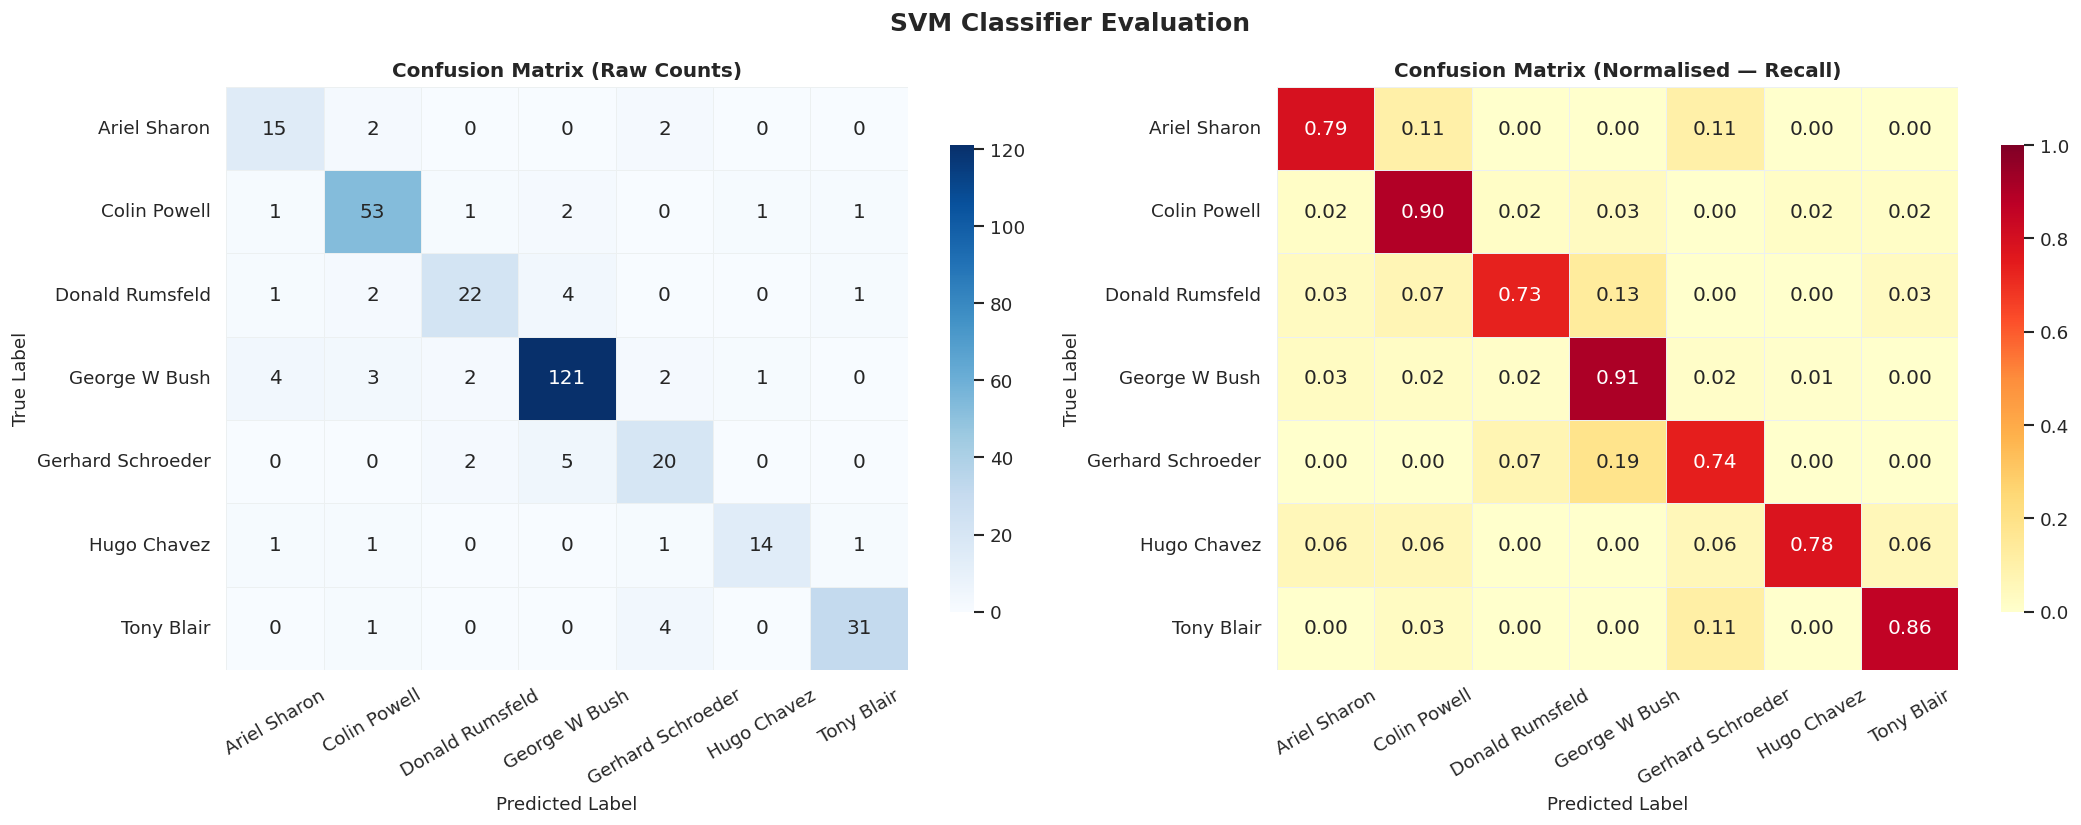

In [10]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred, labels=np.arange(n_classes))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('SVM Classifier Evaluation', fontsize=15, fontweight='bold')

# ── Left: Raw counts ──────────────────────────────────────────────────────────
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=names, yticklabels=names,
    linewidths=0.5, linecolor='#ecf0f1',
    ax=axes[0], cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

# ── Right: Normalised (recall per class) ──────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=names, yticklabels=names,
    linewidths=0.5, linecolor='#ecf0f1',
    ax=axes[1], vmin=0, vmax=1, cbar_kws={'shrink': 0.8}
)
axes[1].set_title('Confusion Matrix (Normalised — Recall)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

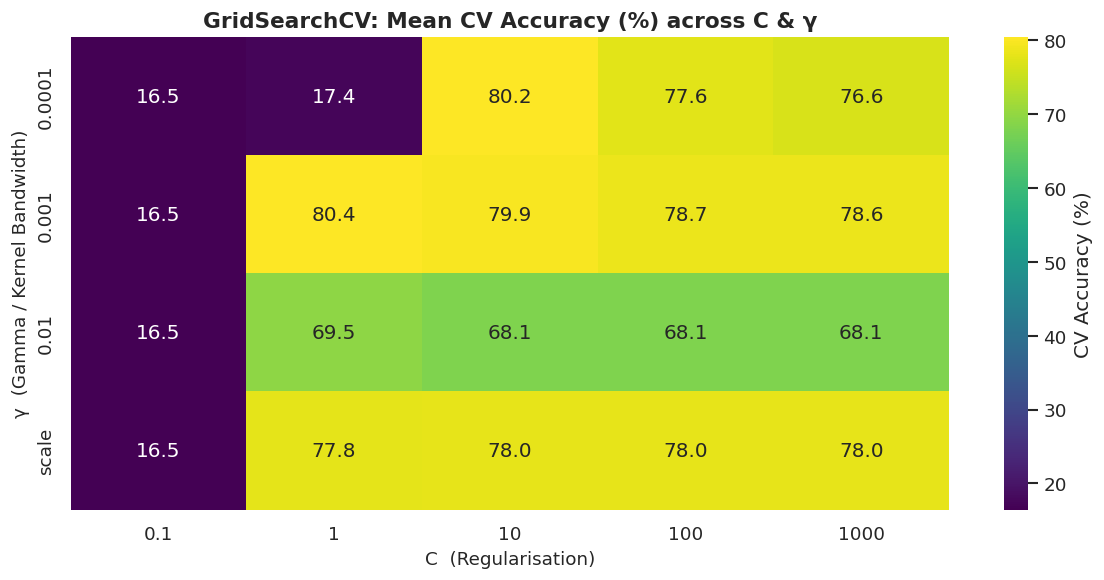

In [11]:
# ── GridSearch Heatmap: C vs gamma ───────────────────────────────────────────
results   = grid_search.cv_results_
cv_scores = results['mean_test_score']

C_values     = sorted(set(p['svm__C']     for p in results['params']))
gamma_values = sorted(
    set(p['svm__gamma'] for p in results['params']),
    key=lambda g: float(g) if g != 'scale' else 999
)

score_matrix = np.zeros((len(gamma_values), len(C_values)))
for i, gamma in enumerate(gamma_values):
    for j, C in enumerate(C_values):
        mask = [
            p['svm__C'] == C and p['svm__gamma'] == gamma
            for p in results['params']
        ]
        score_matrix[i, j] = cv_scores[np.where(mask)[0][0]] * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    score_matrix, annot=True, fmt='.1f', cmap='viridis',
    xticklabels=[str(c) for c in C_values],
    yticklabels=[str(g) for g in gamma_values],
    ax=ax, cbar_kws={'label': 'CV Accuracy (%)'}
)
ax.set_title('GridSearchCV: Mean CV Accuracy (%) across C & γ', fontsize=13, fontweight='bold')
ax.set_xlabel('C  (Regularisation)', fontsize=11)
ax.set_ylabel('γ  (Gamma / Kernel Bandwidth)', fontsize=11)
plt.tight_layout()
plt.show()

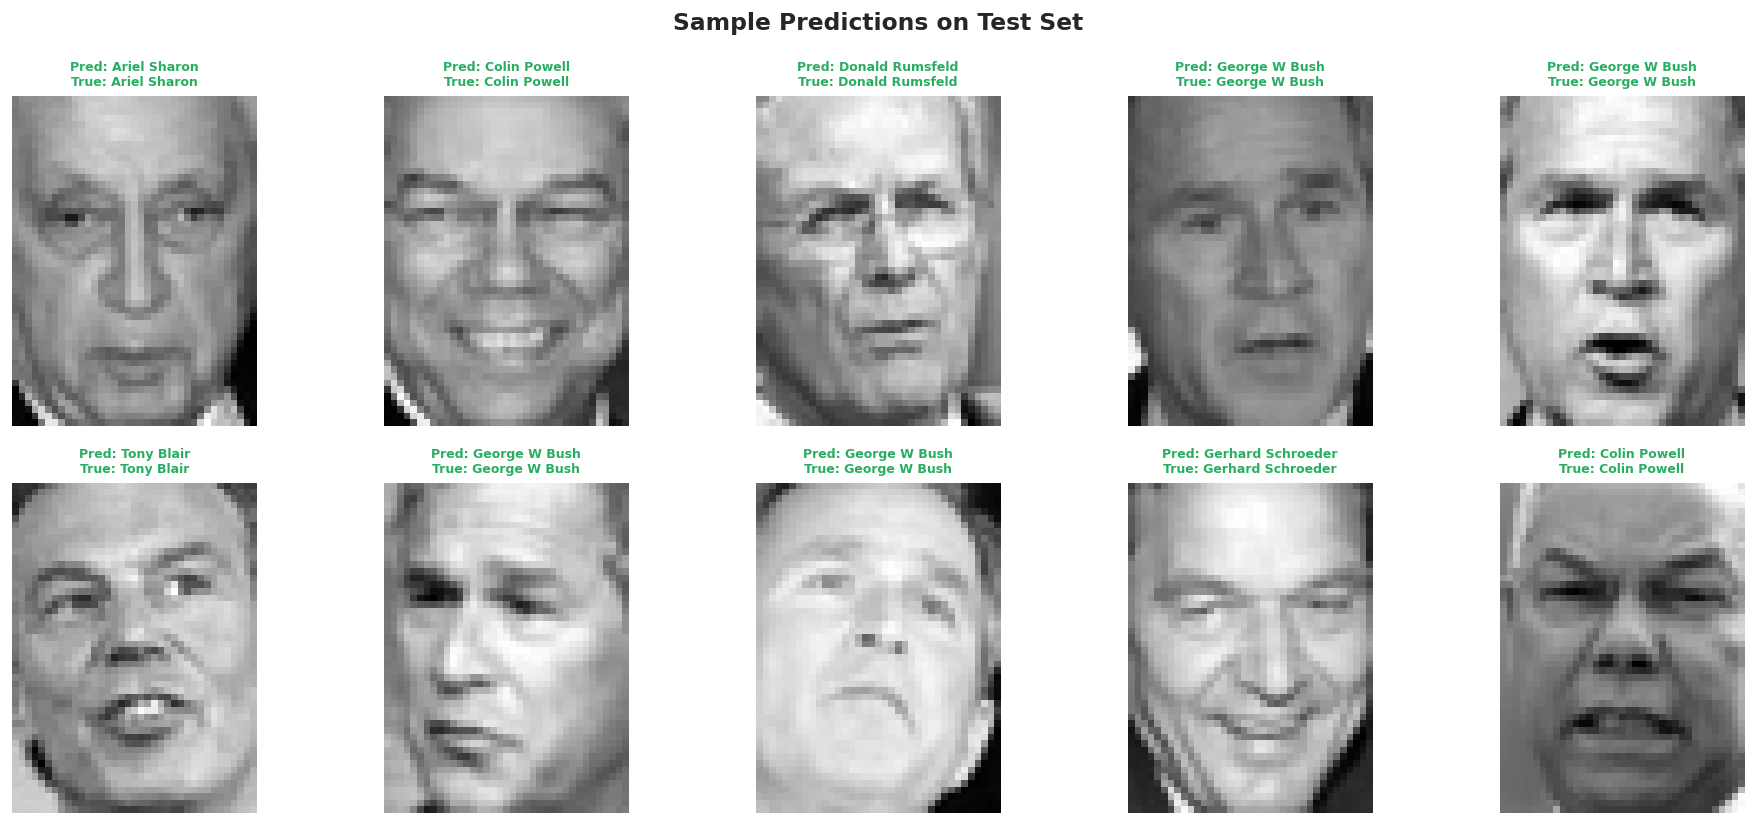

🟢 Green border = Correct   🔴 Red border = Incorrect


In [12]:
# ── Show some prediction examples ─────────────────────────────────────────────
rng        = np.random.RandomState(7)
sample_idx = rng.choice(len(y_test), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample Predictions on Test Set', fontsize=14, fontweight='bold')

test_images = X_test.reshape(-1, h, w)
for ax, idx in zip(axes.ravel(), sample_idx):
    pred  = names[y_pred[idx]]
    true  = names[y_test[idx]]
    color = '#27ae60' if pred == true else '#e74c3c'
    ax.imshow(test_images[idx], cmap='gray')
    ax.set_title(f'Pred: {pred}\nTrue: {true}', fontsize=7.5,
                 color=color, fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

plt.tight_layout()
plt.show()
print('🟢 Green border = Correct   🔴 Red border = Incorrect')

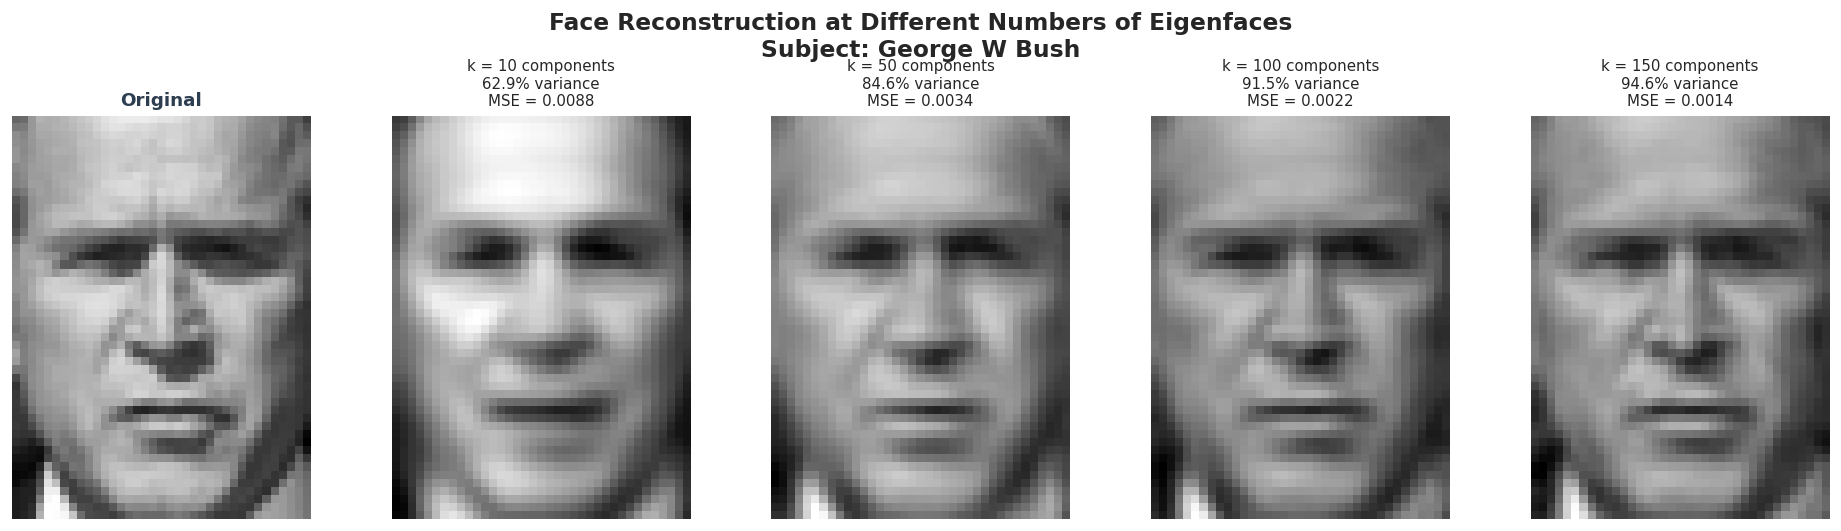

In [13]:
def reconstruct_face(face_vec, mean_vec, components, k):
    """Reconstruct a face using the top-k eigenfaces."""
    centered    = face_vec - mean_vec
    projections = components[:k] @ centered          # k coefficients
    recon       = mean_vec + components[:k].T @ projections
    return recon

# ── Pick a sample from the test set ──────────────────────────────────────────
SAMPLE_IDX   = 5
sample_face  = X_test[SAMPLE_IDX]
sample_name  = names[y_test[SAMPLE_IDX]]

components_k = [10, 50, 100, 150]
reconstructions = [
    reconstruct_face(sample_face, mean_face_vec, pca.components_, k)
    for k in components_k
]

# ── Compute reconstruction errors ─────────────────────────────────────────────
errors = [
    np.mean((sample_face - r) ** 2) for r in reconstructions
]

# ── Plot ──────────────────────────────────────────────────────────────────────
n_cols = len(components_k) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(3.2 * n_cols, 4.5))
fig.suptitle(
    f'Face Reconstruction at Different Numbers of Eigenfaces\nSubject: {sample_name}',
    fontsize=14, fontweight='bold'
)

# Original
axes[0].imshow(sample_face.reshape(h, w), cmap='gray')
axes[0].set_title('Original', fontsize=11, fontweight='bold', color='#2c3e50')
axes[0].axis('off')
axes[0].set_xlabel('Full resolution', fontsize=9)

cmap_opts = ['Oranges', 'YlOrRd', 'RdPu', 'Blues']
for ax, k, recon, err, cm_name in zip(axes[1:], components_k, reconstructions, errors, cmap_opts):
    ax.imshow(recon.reshape(h, w), cmap='gray')
    var_pct = np.cumsum(pca.explained_variance_ratio_)[k-1] * 100
    ax.set_title(f'k = {k} components\n{var_pct:.1f}% variance\nMSE = {err:.4f}',
                 fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

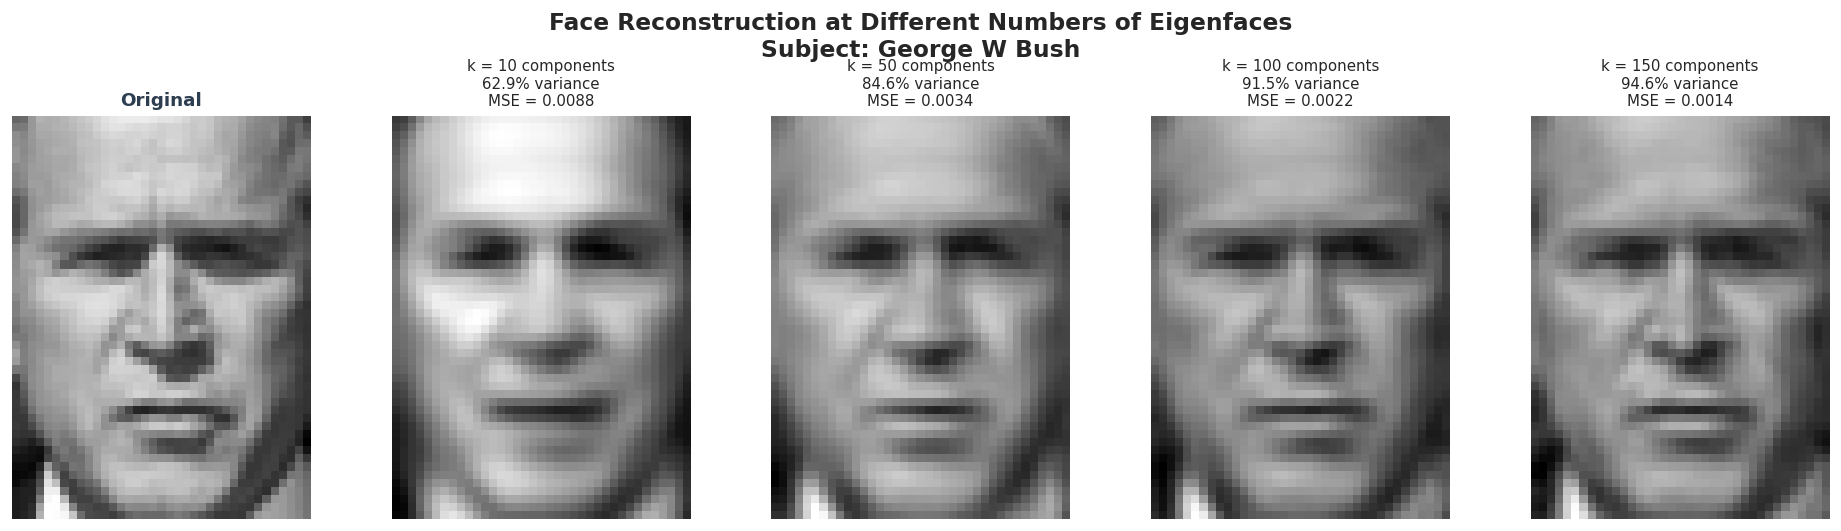

In [14]:
def reconstruct_face(face_vec, mean_vec, components, k):
    """Reconstruct a face using the top-k eigenfaces."""
    centered    = face_vec - mean_vec
    projections = components[:k] @ centered          # k coefficients
    recon       = mean_vec + components[:k].T @ projections
    return recon

# ── Pick a sample from the test set ──────────────────────────────────────────
SAMPLE_IDX   = 5
sample_face  = X_test[SAMPLE_IDX]
sample_name  = names[y_test[SAMPLE_IDX]]

components_k = [10, 50, 100, 150]
reconstructions = [
    reconstruct_face(sample_face, mean_face_vec, pca.components_, k)
    for k in components_k
]

# ── Compute reconstruction errors ─────────────────────────────────────────────
errors = [
    np.mean((sample_face - r) ** 2) for r in reconstructions
]

# ── Plot ──────────────────────────────────────────────────────────────────────
n_cols = len(components_k) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(3.2 * n_cols, 4.5))
fig.suptitle(
    f'Face Reconstruction at Different Numbers of Eigenfaces\nSubject: {sample_name}',
    fontsize=14, fontweight='bold'
)

# Original
axes[0].imshow(sample_face.reshape(h, w), cmap='gray')
axes[0].set_title('Original', fontsize=11, fontweight='bold', color='#2c3e50')
axes[0].axis('off')
axes[0].set_xlabel('Full resolution', fontsize=9)

cmap_opts = ['Oranges', 'YlOrRd', 'RdPu', 'Blues']
for ax, k, recon, err, cm_name in zip(axes[1:], components_k, reconstructions, errors, cmap_opts):
    ax.imshow(recon.reshape(h, w), cmap='gray')
    var_pct = np.cumsum(pca.explained_variance_ratio_)[k-1] * 100
    ax.set_title(f'k = {k} components\n{var_pct:.1f}% variance\nMSE = {err:.4f}',
                 fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()